# Final Project Peramalan Penjualan Harian `test.csv` Menggunakan Random Forest Regression

Notebook ini dibuat untuk proyek akhir mata kuliah peramalan. Tujuan utama notebook ini adalah memprediksi `number_sold` pada periode uji November-Desember 2019 dan membuat forecast 30 hari setelah `2019-12-31` untuk setiap kombinasi `store` dan `product`.

Metode utama yang digunakan adalah **Random Forest Regression** karena model ini cocok untuk data tabular time series dengan fitur kalender, lag, rolling mean, dan rolling standard deviation. Evaluasi tetap dilakukan secara kronologis agar tidak terjadi data leakage dari masa depan ke masa lalu.


## Instalasi Library

Cell berikut disediakan agar notebook dapat dijalankan di Google Colab atau environment lokal yang belum memiliki library yang dibutuhkan. Jika semua library sudah tersedia, cell ini boleh dilewati.


In [27]:
!pip install scikit-learn pandas numpy matplotlib seaborn


## Ruang Lingkup Notebook

Notebook ini berfokus pada:

1. Memuat dan memahami dataset `test.csv`.
2. Melakukan validasi struktur panel harian `store + product`.
3. Melakukan exploratory data analysis untuk melihat pola penjualan.
4. Membuat fitur time series: kalender, kategori, lag, rolling average, dan rolling standard deviation.
5. Membagi data secara kronologis: Januari-Oktober 2019 sebagai train dan November-Desember 2019 sebagai test.
6. Membandingkan baseline sederhana dengan dua varian Random Forest.
7. Mengevaluasi model memakai MAE, RMSE, MAPE, sMAPE, WMAPE, dan R2.
8. Melakukan diagnostik error dan interpretasi feature importance.
9. Membuat forecast recursive 30 hari untuk semua kombinasi `store + product`.


In [28]:
# Import library yang dibutuhkan
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

DATA_PATH = "test.csv"
RANDOM_STATE = 42
FORECAST_HORIZON = 30


## Deskripsi Dataset

Dataset `test.csv` berisi data penjualan harian tahun 2019 dengan empat kolom utama:

- `Date`: tanggal observasi.
- `store`: kode toko.
- `product`: kode produk.
- `number_sold`: jumlah unit terjual.

Unit analisis notebook ini adalah panel harian untuk setiap kombinasi `store + product`. Dengan 7 store dan 10 product, dataset diharapkan memiliki 70 kombinasi. Karena tahun 2019 memiliki 365 hari, total baris yang valid adalah 70 x 365 = 25.550 baris.


In [29]:
# Load dataset
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (25550, 4)


,Date,store,product,number_sold
0,2019-01-01,0,0,845
1,2019-01-02,0,0,851
2,2019-01-03,0,0,840
3,2019-01-04,0,0,842
4,2019-01-05,0,0,845


In [30]:
# Basic data inspection
inspection = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_values": df.isna().sum().values,
    "unique_values": df.nunique().values,
})

expected_columns = ["Date", "store", "product", "number_sold"]
assert list(df.columns) == expected_columns, f"Kolom tidak sesuai: {list(df.columns)}"
assert df.shape == (25550, 4), f"Shape dataset tidak sesuai: {df.shape}"
assert df[expected_columns].isna().sum().sum() == 0, "Masih ada missing value pada kolom utama"

inspection


,column,dtype,missing_values,unique_values
0,Date,str,0,365
1,store,int64,0,7
2,product,int64,0,10
3,number_sold,int64,0,815


## Persiapan Kolom Tanggal

Kolom `Date` dikonversi menjadi tipe datetime menggunakan format `YYYY-MM-DD`. Data kemudian diurutkan berdasarkan `store`, `product`, dan `Date` agar fitur lag dan rolling dapat dihitung secara kronologis.

Pembagian kronologis penting dalam peramalan karena model hanya boleh belajar dari informasi masa lalu untuk memprediksi periode berikutnya.


In [31]:
# Parse date dan cleaning tipe data
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
df["store"] = df["store"].astype(int)
df["product"] = df["product"].astype(int)
df["number_sold"] = pd.to_numeric(df["number_sold"], errors="coerce")

df = df.sort_values(["store", "product", "Date"]).reset_index(drop=True)

summary = pd.DataFrame({
    "metric": [
        "date_min", "date_max", "total_days", "total_store", "total_product",
        "total_store_product_combination", "duplicate_Date_store_product",
    ],
    "value": [
        df["Date"].min().date(),
        df["Date"].max().date(),
        df["Date"].nunique(),
        df["store"].nunique(),
        df["product"].nunique(),
        df[["store", "product"]].drop_duplicates().shape[0],
        df.duplicated(["Date", "store", "product"]).sum(),
    ],
})

assert df["Date"].min() == pd.Timestamp("2019-01-01")
assert df["Date"].max() == pd.Timestamp("2019-12-31")
assert df["Date"].nunique() == 365
assert df[["store", "product"]].drop_duplicates().shape[0] == 70
assert df.duplicated(["Date", "store", "product"]).sum() == 0

summary


,metric,value
0,date_min,2019-01-01
1,date_max,2019-12-31
2,total_days,365
3,total_store,7
4,total_product,10
5,total_store_product_combination,70
6,duplicate_Date_store_product,0


## Validasi Panel Harian `store + product`

Validasi ini memastikan setiap kombinasi toko dan produk memiliki observasi lengkap dari `2019-01-01` sampai `2019-12-31`. Panel yang lengkap membuat proses supervised learning dan recursive forecast lebih stabil karena setiap kombinasi mempunyai riwayat yang sama panjang.


In [32]:
# Validasi kelengkapan panel harian per store + product
panel_validation = (
    df.groupby(["store", "product"])
    .agg(
        start_date=("Date", "min"),
        end_date=("Date", "max"),
        total_days=("Date", "nunique"),
        total_rows=("Date", "size"),
        total_sales=("number_sold", "sum"),
        mean_sales=("number_sold", "mean"),
    )
    .reset_index()
)

panel_validation["is_complete"] = (
    (panel_validation["start_date"] == pd.Timestamp("2019-01-01"))
    & (panel_validation["end_date"] == pd.Timestamp("2019-12-31"))
    & (panel_validation["total_days"] == 365)
    & (panel_validation["total_rows"] == 365)
)

assert panel_validation["is_complete"].all(), "Ada kombinasi store + product yang tidak lengkap"

panel_validation.head(10)


,store,product,start_date,end_date,total_days,total_rows,total_sales,mean_sales,is_complete
0,0,0,2019-01-01,2019-12-31,365,365,310370,850.33,True
1,0,1,2019-01-01,2019-12-31,365,365,235019,643.89,True
2,0,2,2019-01-01,2019-12-31,365,365,361432,990.22,True
3,0,3,2019-01-01,2019-12-31,365,365,326340,894.08,True
4,0,4,2019-01-01,2019-12-31,365,365,338617,927.72,True
5,0,5,2019-01-01,2019-12-31,365,365,351254,962.34,True
6,0,6,2019-01-01,2019-12-31,365,365,312696,856.70,True
7,0,7,2019-01-01,2019-12-31,365,365,375530,"1,028.85",True
8,0,8,2019-01-01,2019-12-31,365,365,192203,526.58,True
9,0,9,2019-01-01,2019-12-31,365,365,315216,863.61,True


## Exploratory Data Analysis

EDA dilakukan untuk melihat skala target, variasi antar toko dan produk, serta pola kalender harian. Informasi ini membantu menjelaskan mengapa fitur kalender, lag, dan rolling dipakai pada model Random Forest.


In [33]:
# Statistik target number_sold
target_summary = df["number_sold"].describe().to_frame("number_sold")
target_summary.loc["missing"] = df["number_sold"].isna().sum()
target_summary.loc["zero_or_negative"] = (df["number_sold"] <= 0).sum()

target_summary


,number_sold
count,"25,550.00"
mean,790.05
std,211.92
min,234.00
25%,722.00
50%,852.00
75%,933.00
max,"1,110.00"
missing,0.00
zero_or_negative,0.00


In [34]:
# Agregasi penjualan per store dan product
sales_by_store = (
    df.groupby("store", as_index=False)
    .agg(total_sales=("number_sold", "sum"), mean_sales=("number_sold", "mean"))
    .sort_values("mean_sales", ascending=False)
)

sales_by_product = (
    df.groupby("product", as_index=False)
    .agg(total_sales=("number_sold", "sum"), mean_sales=("number_sold", "mean"))
    .sort_values("mean_sales", ascending=False)
)

display(sales_by_store)
display(sales_by_product)


,store,total_sales,mean_sales
4,4,3592764,984.32
5,5,3296151,903.06
6,6,3179193,871.01
0,0,3118677,854.43
2,2,3094579,847.83
1,1,2654482,727.26
3,3,1249952,342.45


,product,total_sales,mean_sales
7,7,2148774,841.01
4,4,2091571,818.62
5,5,2087577,817.06
6,6,2086448,816.61
1,1,2071485,810.76
9,9,2044775,800.30
2,2,2011091,787.12
3,3,1959347,766.87
0,0,1907659,746.64
8,8,1777071,695.53


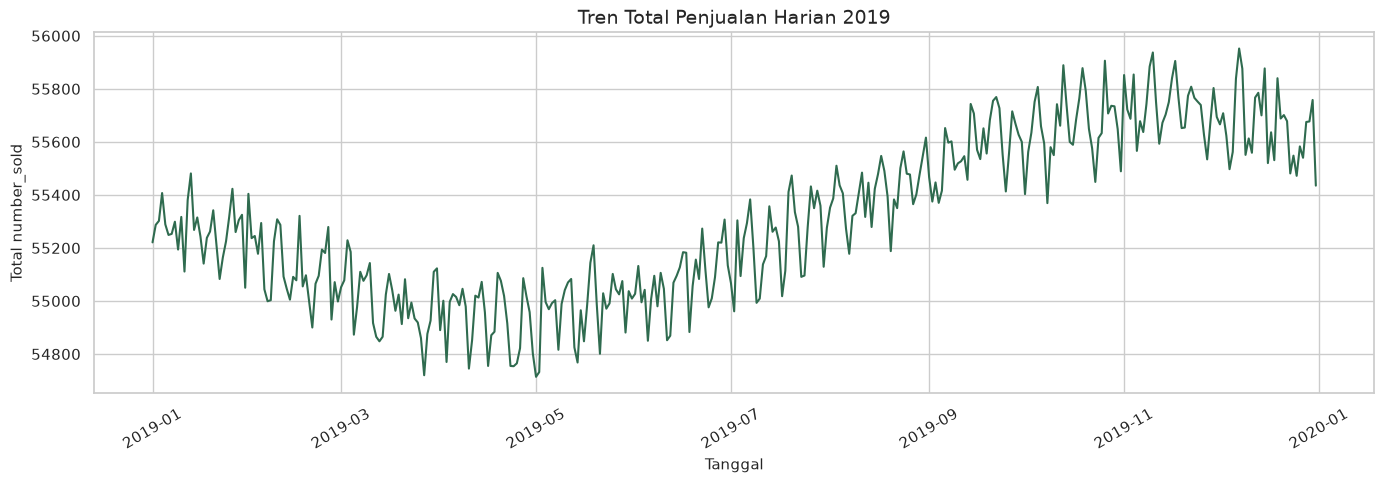

In [35]:
# Tren total penjualan harian selama 2019
daily_sales = df.groupby("Date", as_index=False)["number_sold"].sum()

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=daily_sales, x="Date", y="number_sold", ax=ax, color="#2F6B4F")
ax.set_title("Tren Total Penjualan Harian 2019")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Total number_sold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


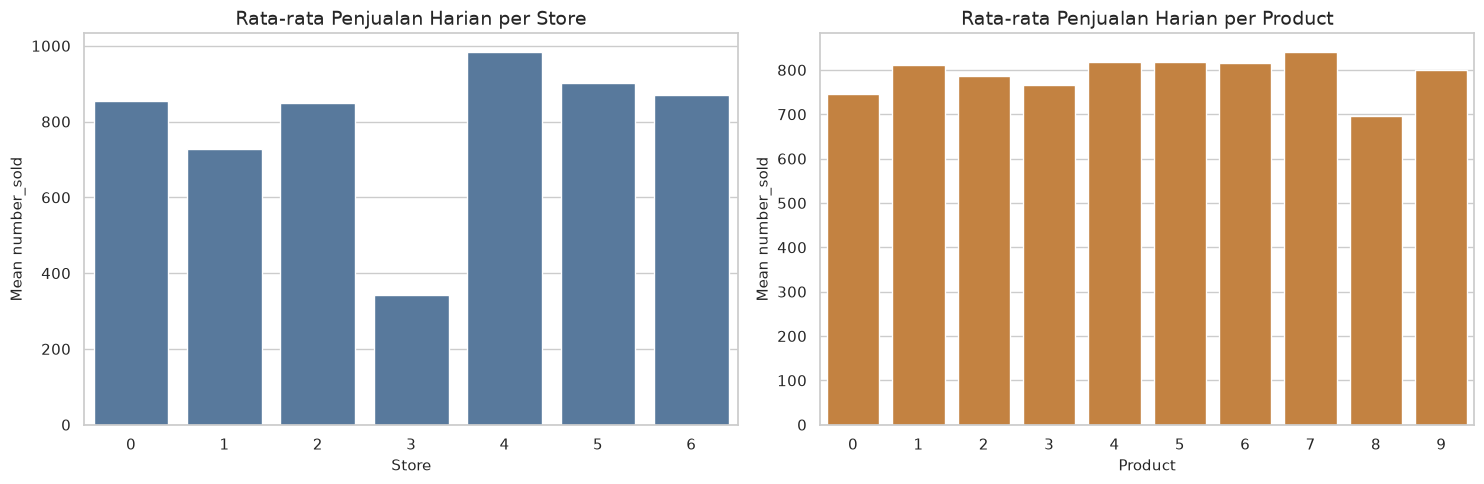

In [36]:
# Rata-rata penjualan per store dan product
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=sales_by_store, x="store", y="mean_sales", ax=axes[0], color="#4C78A8")
axes[0].set_title("Rata-rata Penjualan Harian per Store")
axes[0].set_xlabel("Store")
axes[0].set_ylabel("Mean number_sold")

sns.barplot(data=sales_by_product, x="product", y="mean_sales", ax=axes[1], color="#D9822B")
axes[1].set_title("Rata-rata Penjualan Harian per Product")
axes[1].set_xlabel("Product")
axes[1].set_ylabel("Mean number_sold")

plt.tight_layout()
plt.show()


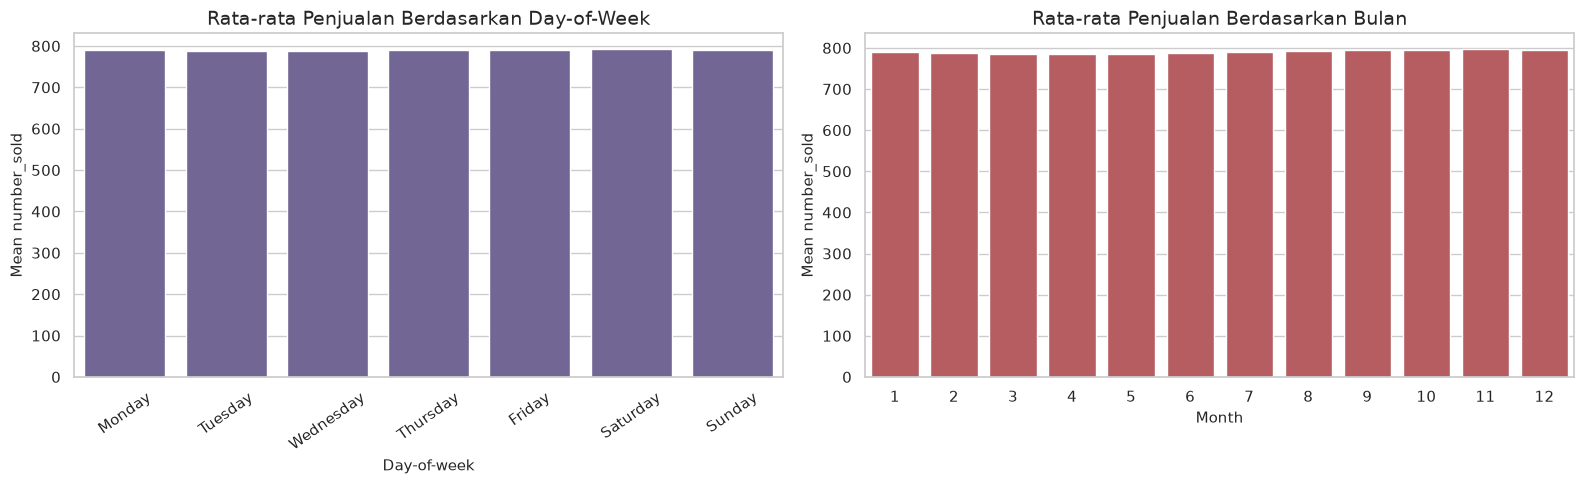

In [37]:
# Pola kalender: day-of-week dan month
calendar_eda = df.copy()
calendar_eda["day_name"] = calendar_eda["Date"].dt.day_name()
calendar_eda["day_of_week"] = calendar_eda["Date"].dt.dayofweek
calendar_eda["month"] = calendar_eda["Date"].dt.month

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=calendar_eda, x="day_name", y="number_sold", order=dow_order, estimator="mean", errorbar=None, ax=axes[0], color="#6F5E9C")
axes[0].set_title("Rata-rata Penjualan Berdasarkan Day-of-Week")
axes[0].set_xlabel("Day-of-week")
axes[0].set_ylabel("Mean number_sold")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(data=calendar_eda, x="month", y="number_sold", estimator="mean", errorbar=None, ax=axes[1], color="#C44E52")
axes[1].set_title("Rata-rata Penjualan Berdasarkan Bulan")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Mean number_sold")

plt.tight_layout()
plt.show()


## Feature Engineering Time Series

Fitur dibuat per kombinasi `store + product` agar karakteristik setiap seri tidak bercampur. Fitur lag dan rolling selalu dihitung dari nilai historis sebelum hari target dengan menggunakan `groupby(...).shift(...)`, sehingga tidak ada leakage dari nilai target hari yang sama.

Fitur utama:

- Kalender: `day`, `month`, `dayofweek`, `dayofyear`, `weekofyear`, `is_weekend`.
- Identitas panel: `store`, `product`.
- Lag: `lag_1`, `lag_7`, `lag_14`, `lag_28`.
- Rolling: `roll_mean_7`, `roll_std_7`, `roll_mean_28`.


In [38]:
# Membuat fitur kalender, lag, dan rolling per store + product
model_df = df.copy()
model_df["day"] = model_df["Date"].dt.day
model_df["month"] = model_df["Date"].dt.month
model_df["dayofweek"] = model_df["Date"].dt.dayofweek
model_df["dayofyear"] = model_df["Date"].dt.dayofyear
model_df["weekofyear"] = model_df["Date"].dt.isocalendar().week.astype(int)
model_df["is_weekend"] = model_df["dayofweek"].isin([5, 6]).astype(int)

panel_group = model_df.groupby(["store", "product"])["number_sold"]
for lag in [1, 7, 14, 28]:
    model_df[f"lag_{lag}"] = panel_group.shift(lag)

model_df["roll_mean_7"] = panel_group.transform(lambda s: s.shift(1).rolling(window=7, min_periods=7).mean())
model_df["roll_std_7"] = panel_group.transform(lambda s: s.shift(1).rolling(window=7, min_periods=7).std())
model_df["roll_mean_28"] = panel_group.transform(lambda s: s.shift(1).rolling(window=28, min_periods=28).mean())

FEATURE_COLUMNS = [
    "store", "product", "day", "month", "dayofweek", "dayofyear", "weekofyear", "is_weekend",
    "lag_1", "lag_7", "lag_14", "lag_28", "roll_mean_7", "roll_std_7", "roll_mean_28",
]
TARGET_COLUMN = "number_sold"

supervised_df = model_df.dropna(subset=FEATURE_COLUMNS + [TARGET_COLUMN]).reset_index(drop=True)

assert supervised_df[FEATURE_COLUMNS + [TARGET_COLUMN]].isna().sum().sum() == 0, "Dataset supervised masih memiliki NaN"

feature_check = pd.DataFrame({
    "dataset": ["raw", "supervised_after_lag_rolling"],
    "rows": [len(df), len(supervised_df)],
    "date_min": [df["Date"].min().date(), supervised_df["Date"].min().date()],
    "date_max": [df["Date"].max().date(), supervised_df["Date"].max().date()],
})

feature_check


,dataset,rows,date_min,date_max
0,raw,25550,2019-01-01,2019-12-31
1,supervised_after_lag_rolling,23590,2019-01-29,2019-12-31


In [39]:
# Contoh hasil feature engineering
supervised_df[["Date", "store", "product", "number_sold"] + FEATURE_COLUMNS[-7:]].head(10)


,Date,store,product,number_sold,lag_1,lag_7,lag_14,lag_28,roll_mean_7,roll_std_7,roll_mean_28
0,2019-01-29,0,0,883,849.00,856.00,868.00,845.00,862.43,9.09,857.68
1,2019-01-30,0,0,875,883.00,871.00,867.00,851.00,866.29,11.35,859.04
2,2019-01-31,0,0,874,875.00,863.00,867.00,840.00,866.86,11.73,859.89
3,2019-02-01,0,0,870,874.00,857.00,857.00,842.00,868.43,11.86,861.11
4,2019-02-02,0,0,868,870.00,866.00,857.00,845.00,870.29,10.73,862.11
5,2019-02-03,0,0,874,868.00,875.00,855.00,855.00,870.57,10.63,862.93
6,2019-02-04,0,0,900,874.00,849.00,887.00,822.00,870.43,10.56,863.61
7,2019-02-05,0,0,875,900.00,883.00,856.00,850.00,877.71,10.90,866.39
8,2019-02-06,0,0,883,875.00,875.00,871.00,868.00,876.57,10.67,867.29
9,2019-02-07,0,0,879,883.00,874.00,863.00,849.00,877.71,10.90,867.82


## Pembagian Data Train dan Test

Data dibagi secara kronologis:

- Train: fitur valid sampai `2019-10-31`.
- Test: `2019-11-01` sampai `2019-12-31`.

Split tidak dilakukan secara acak karena masalah yang diselesaikan adalah peramalan. Periode test merepresentasikan data masa depan yang belum dilihat model saat training.


In [40]:
# Split kronologis
train_end = pd.Timestamp("2019-10-31")
test_start = pd.Timestamp("2019-11-01")
test_end = pd.Timestamp("2019-12-31")

train_df = supervised_df[supervised_df["Date"] <= train_end].copy()
test_df = supervised_df[(supervised_df["Date"] >= test_start) & (supervised_df["Date"] <= test_end)].copy()

X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET_COLUMN]
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET_COLUMN]

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(train_df), len(test_df)],
    "date_min": [train_df["Date"].min().date(), test_df["Date"].min().date()],
    "date_max": [train_df["Date"].max().date(), test_df["Date"].max().date()],
    "store_product_combination": [
        train_df[["store", "product"]].drop_duplicates().shape[0],
        test_df[["store", "product"]].drop_duplicates().shape[0],
    ],
})

assert test_df["Date"].min() == test_start
assert test_df["Date"].max() == test_end
assert train_df["Date"].max() == train_end

split_summary


,split,rows,date_min,date_max,store_product_combination
0,train,19320,2019-01-29,2019-10-31,70
1,test,4270,2019-11-01,2019-12-31,70


## Pemilihan Model dan Evaluasi

Empat pendekatan dibandingkan pada periode test:

1. `Baseline Lag-7`: prediksi memakai nilai 7 hari sebelumnya.
2. `Baseline Lag-28`: prediksi memakai nilai 28 hari sebelumnya.
3. `Random Forest`: model Random Forest pada skala asli `number_sold`.
4. `Random Forest Log Target`: Random Forest yang dilatih pada `log1p(number_sold)`, lalu hasil prediksi dikembalikan ke skala asli dengan `expm1`.

Model final dipilih dari dua varian Random Forest berdasarkan WMAPE terkecil pada test set. Semua metric dihitung pada skala asli `number_sold`.


In [41]:
# Fungsi metric evaluasi
def mean_absolute_percentage_error_safe(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def symmetric_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = np.abs(y_true) + np.abs(y_pred)
    mask = denominator != 0
    return np.mean(2 * np.abs(y_pred[mask] - y_true[mask]) / denominator[mask]) * 100


def weighted_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100


def evaluate_predictions(model_name, y_true, y_pred):
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.maximum(y_pred, 0)
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mean_absolute_percentage_error_safe(y_true, y_pred),
        "sMAPE": symmetric_mape(y_true, y_pred),
        "WMAPE": weighted_mape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


In [42]:
# Training baseline dan Random Forest
lag7_pred = test_df["lag_7"].to_numpy()
lag28_pred = test_df["lag_28"].to_numpy()

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_log_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_log_model.fit(X_train, np.log1p(y_train))
rf_log_pred = np.expm1(rf_log_model.predict(X_test))
rf_log_pred = np.maximum(rf_log_pred, 0)

metrics_df = pd.DataFrame([
    evaluate_predictions("Baseline Lag-7", y_test, lag7_pred),
    evaluate_predictions("Baseline Lag-28", y_test, lag28_pred),
    evaluate_predictions("Random Forest", y_test, rf_pred),
    evaluate_predictions("Random Forest Log Target", y_test, rf_log_pred),
]).sort_values("WMAPE").reset_index(drop=True)

assert metrics_df.shape[0] == 4
assert set(["MAE", "RMSE", "MAPE", "sMAPE", "WMAPE", "R2"]).issubset(metrics_df.columns)

metrics_df


,Model,MAE,RMSE,MAPE,sMAPE,WMAPE,R2
0,Random Forest Log Target,10.00,12.53,1.42,1.42,1.26,1.00
1,Random Forest,10.01,12.54,1.42,1.42,1.26,1.00
2,Baseline Lag-7,11.61,14.56,1.64,1.64,1.46,1.00
3,Baseline Lag-28,14.51,18.36,2.00,2.00,1.82,0.99


In [43]:
# Pilih model final hanya dari varian Random Forest berdasarkan WMAPE
rf_metrics = metrics_df[metrics_df["Model"].isin(["Random Forest", "Random Forest Log Target"])].copy()
best_rf_name = rf_metrics.sort_values("WMAPE").iloc[0]["Model"]

if best_rf_name == "Random Forest Log Target":
    best_model = rf_log_model
    best_pred = rf_log_pred
    best_uses_log_target = True
else:
    best_model = rf_model
    best_pred = rf_pred
    best_uses_log_target = False

best_model_summary = metrics_df[metrics_df["Model"] == best_rf_name].reset_index(drop=True)
print(f"Model final berdasarkan WMAPE test set: {best_rf_name}")
best_model_summary


Model final berdasarkan WMAPE test set: Random Forest Log Target


,Model,MAE,RMSE,MAPE,sMAPE,WMAPE,R2
0,Random Forest Log Target,10.00,12.53,1.42,1.42,1.26,1.00


## Tabel Hasil Prediksi Test Set

Tabel berikut adalah tabel evaluasi pada data test, bukan forecast masa depan. Periode test memiliki nilai aktual dari `test.csv`, yaitu `2019-11-01` sampai `2019-12-31`, sehingga setiap baris dapat membandingkan `Actual number_sold` dengan `Predicted number_sold` dari model final. Kolom error digunakan untuk analisis diagnostik pada bagian berikutnya.

In [44]:
# Tabel prediksi test set model final
prediction_results = test_df[["Date", "store", "product", "number_sold"]].copy()
prediction_results = prediction_results.rename(columns={"number_sold": "Actual number_sold"})
prediction_results["Predicted number_sold"] = np.maximum(best_pred, 0)
prediction_results["Error"] = prediction_results["Actual number_sold"] - prediction_results["Predicted number_sold"]
prediction_results["Absolute Error"] = prediction_results["Error"].abs()
prediction_results["Absolute Percentage Error"] = prediction_results["Absolute Error"] / prediction_results["Actual number_sold"] * 100

prediction_results = prediction_results[
    [
        "Date",
        "store",
        "product",
        "Actual number_sold",
        "Predicted number_sold",
        "Error",
        "Absolute Error",
        "Absolute Percentage Error",
    ]
]

assert prediction_results["Date"].min() == pd.Timestamp("2019-11-01")
assert prediction_results["Date"].max() == pd.Timestamp("2019-12-31")
assert prediction_results["Actual number_sold"].notna().all()
assert prediction_results["Predicted number_sold"].notna().all()

prediction_results.head(15)

,Date,store,product,Actual number_sold,Predicted number_sold,Error,Absolute Error,Absolute Percentage Error
276,2019-11-01,0,0,817,807.77,9.23,9.23,1.13
277,2019-11-02,0,0,808,812.66,-4.66,4.66,0.58
278,2019-11-03,0,0,824,808.72,15.28,15.28,1.85
279,2019-11-04,0,0,810,804.59,5.41,5.41,0.67
280,2019-11-05,0,0,809,800.48,8.52,8.52,1.05
281,2019-11-06,0,0,807,806.23,0.77,0.77,0.09
282,2019-11-07,0,0,820,809.67,10.33,10.33,1.26
283,2019-11-08,0,0,827,809.69,17.31,17.31,2.09
284,2019-11-09,0,0,833,814.50,18.50,18.50,2.22
285,2019-11-10,0,0,808,816.67,-8.67,8.67,1.07


## Visualisasi Actual vs Predicted

Visualisasi ini membandingkan total aktual dan total prediksi harian pada periode test. Agregasi harian digunakan agar pola umum November-Desember 2019 lebih mudah dibaca.


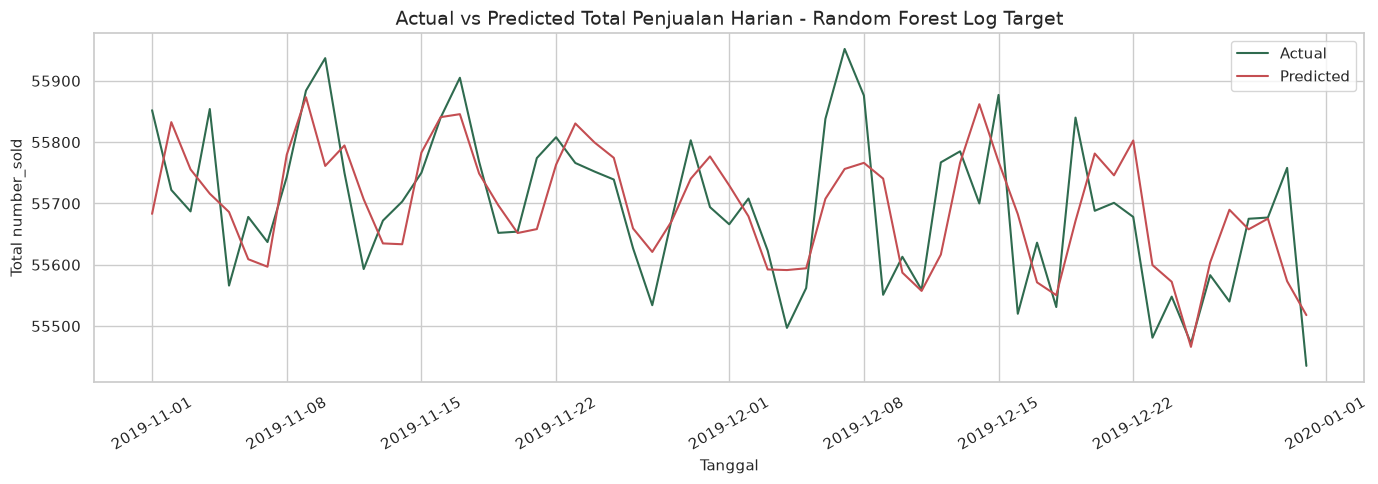

In [45]:
# Plot actual vs predicted pada test set
plot_test = (
    prediction_results.groupby("Date", as_index=False)
    .agg(actual=("Actual number_sold", "sum"), predicted=("Predicted number_sold", "sum"))
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=plot_test, x="Date", y="actual", ax=ax, label="Actual", color="#2F6B4F")
sns.lineplot(data=plot_test, x="Date", y="predicted", ax=ax, label="Predicted", color="#C44E52")
ax.set_title(f"Actual vs Predicted Total Penjualan Harian - {best_rf_name}")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Total number_sold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Diagnostik Error

Diagnostik error digunakan untuk melihat apakah kesalahan model terkonsentrasi pada skala penjualan tertentu atau memiliki distribusi yang ekstrem. Dua visual yang dipakai adalah distribusi absolute percentage error dan hubungan error terhadap nilai aktual.


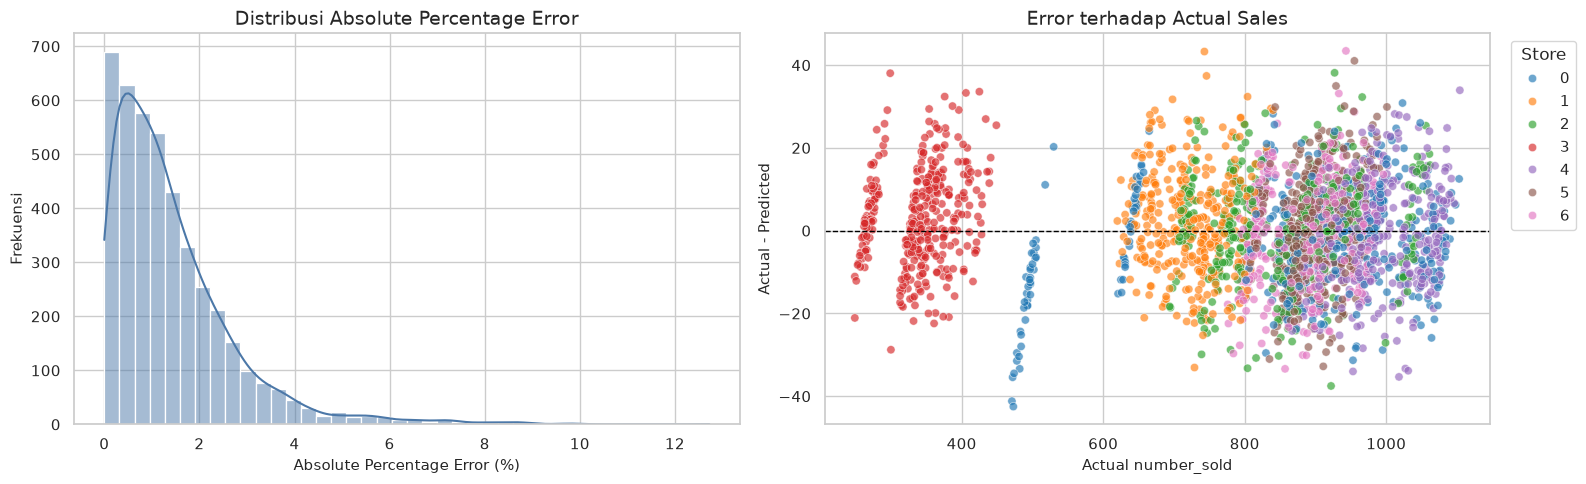

In [46]:
# Distribusi absolute percentage error dan error terhadap actual sales
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(prediction_results["Absolute Percentage Error"], bins=40, kde=True, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribusi Absolute Percentage Error")
axes[0].set_xlabel("Absolute Percentage Error (%)")
axes[0].set_ylabel("Frekuensi")

sns.scatterplot(
    data=prediction_results.sample(min(2500, len(prediction_results)), random_state=RANDOM_STATE),
    x="Actual number_sold",
    y="Error",
    hue="store",
    palette="tab10",
    alpha=0.65,
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].set_title("Error terhadap Actual Sales")
axes[1].set_xlabel("Actual number_sold")
axes[1].set_ylabel("Actual - Predicted")
axes[1].legend(title="Store", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [47]:
# Ringkasan error per store dan product
error_by_store = (
    prediction_results.groupby("store")
    .agg(
        rows=("Actual number_sold", "size"),
        actual_total=("Actual number_sold", "sum"),
        predicted_total=("Predicted number_sold", "sum"),
        mae=("Absolute Error", "mean"),
        wmape=("Absolute Error", lambda s: s.sum()),
    )
    .reset_index()
)
error_by_store["WMAPE"] = error_by_store["wmape"] / error_by_store["actual_total"] * 100
error_by_store = error_by_store.drop(columns="wmape")

error_by_product = (
    prediction_results.groupby("product")
    .agg(
        rows=("Actual number_sold", "size"),
        actual_total=("Actual number_sold", "sum"),
        predicted_total=("Predicted number_sold", "sum"),
        mae=("Absolute Error", "mean"),
        wmape=("Absolute Error", lambda s: s.sum()),
    )
    .reset_index()
)
error_by_product["WMAPE"] = error_by_product["wmape"] / error_by_product["actual_total"] * 100
error_by_product = error_by_product.drop(columns="wmape")

display(error_by_store)
display(error_by_product)


,store,rows,actual_total,predicted_total,mae,WMAPE
0,0,610,531924,"533,706.01",10.94,1.25
1,1,610,441597,"440,395.80",9.59,1.33
2,2,610,524537,"524,610.47",9.64,1.12
3,3,610,208397,"206,601.11",9.33,2.73
4,4,610,607945,"608,298.96",10.33,1.04
5,5,610,546302,"546,106.76",10.55,1.18
6,6,610,536652,"537,678.25",9.59,1.09


,product,rows,actual_total,predicted_total,mae,WMAPE
0,0,427,319874,"319,205.63",9.45,1.26
1,1,427,346276,"346,203.66",9.88,1.22
2,2,427,337633,"338,458.67",10.01,1.27
3,3,427,330130,"330,433.15",9.91,1.28
4,4,427,357053,"356,199.68",10.71,1.28
5,5,427,353154,"352,941.42",9.70,1.17
6,6,427,352873,"353,014.46",10.78,1.30
7,7,427,359646,"359,499.22",9.50,1.13
8,8,427,292497,"292,365.94",10.39,1.52
9,9,427,348218,"349,075.54",9.66,1.18


## Interpretasi Feature Importance

Feature importance dari Random Forest membantu menjelaskan fitur mana yang paling sering digunakan model untuk menurunkan error. Pada data time series seperti ini, fitur lag dan rolling biasanya penting karena penjualan hari ini berkaitan dengan pola historis pada kombinasi `store + product` yang sama.


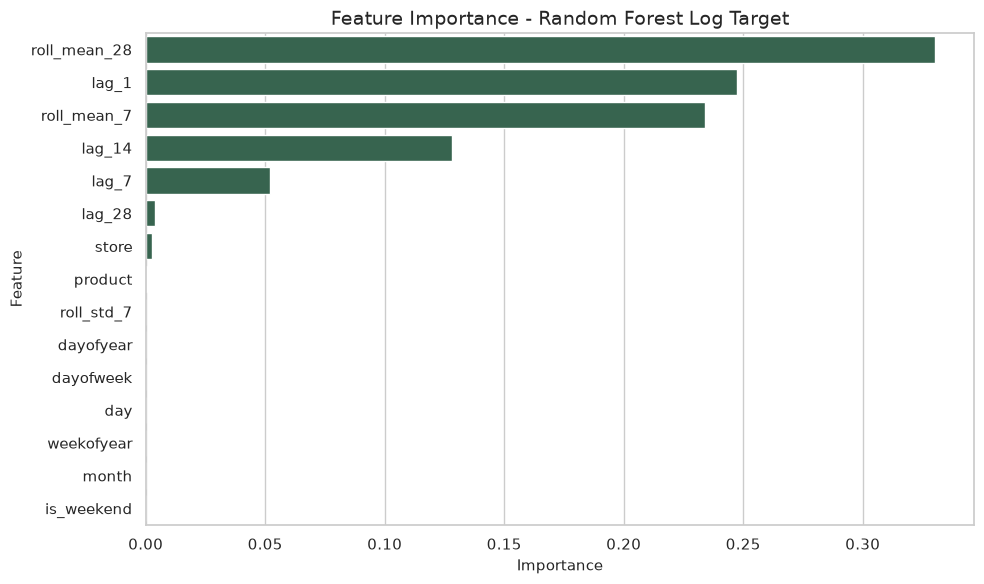

,feature,importance
0,roll_mean_28,0.33
1,lag_1,0.25
2,roll_mean_7,0.23
3,lag_14,0.13
4,lag_7,0.05
5,lag_28,0.00
6,store,0.00
7,product,0.00
8,roll_std_7,0.00
9,dayofyear,0.00


In [48]:
# Feature importance model final
feature_importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": best_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feature_importance, x="importance", y="feature", ax=ax, color="#2F6B4F")
ax.set_title(f"Feature Importance - {best_rf_name}")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

feature_importance


## Forecast Recursive 30 Hari ke Depan

Forecast dilakukan secara recursive dari history lengkap sampai `2019-12-31`. Untuk setiap tanggal forecast, model memprediksi semua 70 kombinasi `store + product`. Setelah prediksi satu hari selesai, hasilnya dimasukkan kembali ke history agar fitur lag dan rolling untuk hari berikutnya tetap tersedia.

Periode forecast adalah `2020-01-01` sampai `2020-01-30`. Dataset `test.csv` hanya berisi data historis sampai `2019-12-31`, sehingga nilai aktual untuk forecast 2020 tidak tersedia di dataset ini. Kolom `Forecasted number_sold` adalah prediksi masa depan, bukan hasil evaluasi terhadap nilai aktual.

In [49]:
# Helper untuk recursive forecast
stores = sorted(df["store"].unique())
products = sorted(df["product"].unique())
panel_keys = sorted(df[["store", "product"]].drop_duplicates().itertuples(index=False, name=None))


def make_feature_row(forecast_date, store, product, history_values):
    values = np.asarray(history_values, dtype=float)
    return {
        "store": int(store),
        "product": int(product),
        "day": forecast_date.day,
        "month": forecast_date.month,
        "dayofweek": forecast_date.dayofweek,
        "dayofyear": forecast_date.dayofyear,
        "weekofyear": int(forecast_date.isocalendar().week),
        "is_weekend": int(forecast_date.dayofweek in [5, 6]),
        "lag_1": values[-1],
        "lag_7": values[-7],
        "lag_14": values[-14],
        "lag_28": values[-28],
        "roll_mean_7": values[-7:].mean(),
        "roll_std_7": values[-7:].std(ddof=1),
        "roll_mean_28": values[-28:].mean(),
    }


def predict_with_final_model(feature_frame):
    raw_pred = best_model.predict(feature_frame[FEATURE_COLUMNS])
    if best_uses_log_target:
        raw_pred = np.expm1(raw_pred)
    return np.maximum(raw_pred, 0)


histories = {
    (store, product): group.sort_values("Date")["number_sold"].astype(float).tolist()
    for (store, product), group in df.groupby(["store", "product"])
}

forecast_rows = []
last_date = df["Date"].max()

for step in range(1, FORECAST_HORIZON + 1):
    forecast_date = last_date + pd.Timedelta(days=step)
    batch_features = pd.DataFrame([
        make_feature_row(forecast_date, store, product, histories[(store, product)])
        for store, product in panel_keys
    ])
    batch_pred = predict_with_final_model(batch_features)

    for (store, product), pred_value in zip(panel_keys, batch_pred):
        pred_value = float(max(pred_value, 0.0))
        forecast_rows.append({
            "Date": forecast_date,
            "store": int(store),
            "product": int(product),
            "Forecasted number_sold": pred_value,
        })
        histories[(store, product)].append(pred_value)

forecast_df = pd.DataFrame(forecast_rows)
forecast_df = forecast_df[["Date", "store", "product", "Forecasted number_sold"]]

assert list(forecast_df.columns) == ["Date", "store", "product", "Forecasted number_sold"]
assert len(forecast_df) == 70 * FORECAST_HORIZON
assert forecast_df["Date"].min() == pd.Timestamp("2020-01-01")
assert forecast_df["Date"].max() == pd.Timestamp("2020-01-30")
assert (forecast_df["Forecasted number_sold"] > 0).all()

forecast_df.head(20)


,Date,store,product,Forecasted number_sold
0,2020-01-01,0,0,848.01
1,2020-01-01,0,1,644.24
2,2020-01-01,0,2,"1,004.48"
3,2020-01-01,0,3,921.63
4,2020-01-01,0,4,"1,010.92"
5,2020-01-01,0,5,997.20
6,2020-01-01,0,6,848.80
7,2020-01-01,0,7,"1,064.65"
8,2020-01-01,0,8,544.59
9,2020-01-01,0,9,885.76


In [50]:
# Ringkasan forecast final
forecast_summary = pd.DataFrame({
    "metric": [
        "model_final", "forecast_start", "forecast_end", "forecast_horizon_days",
        "store_product_combination", "forecast_rows", "min_forecast", "max_forecast", "mean_forecast",
    ],
    "value": [
        best_rf_name,
        forecast_df["Date"].min().date(),
        forecast_df["Date"].max().date(),
        FORECAST_HORIZON,
        forecast_df[["store", "product"]].drop_duplicates().shape[0],
        len(forecast_df),
        forecast_df["Forecasted number_sold"].min(),
        forecast_df["Forecasted number_sold"].max(),
        forecast_df["Forecasted number_sold"].mean(),
    ],
})

forecast_summary


,metric,value
0,model_final,Random Forest Log Target
1,forecast_start,2020-01-01
2,forecast_end,2020-01-30
3,forecast_horizon_days,30
4,store_product_combination,70
5,forecast_rows,2100
6,min_forecast,263.07
7,max_forecast,"1,087.48"
8,mean_forecast,794.81


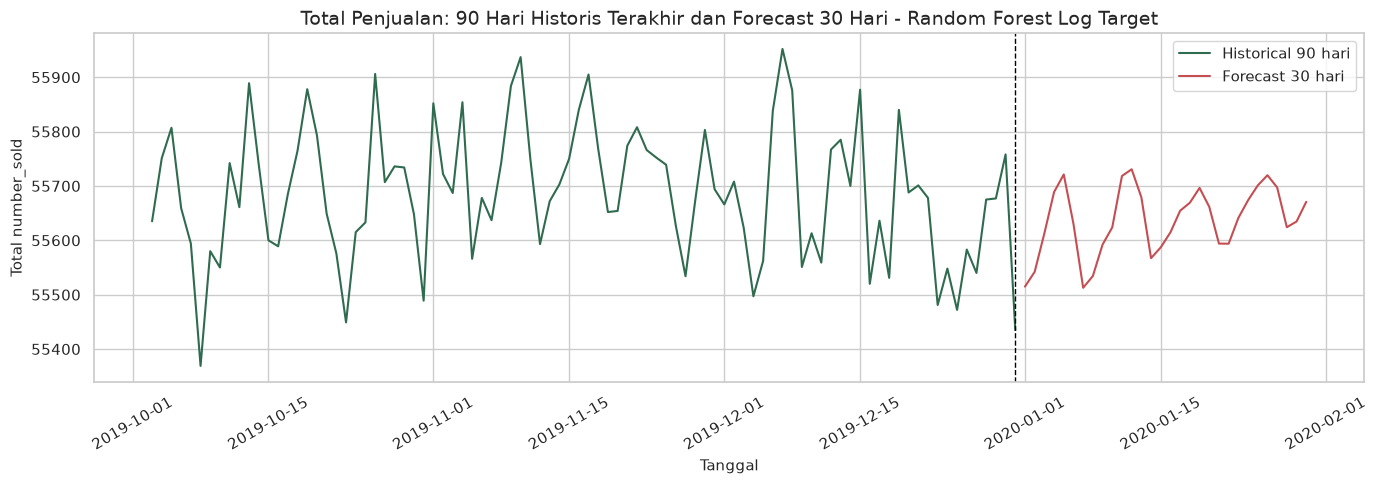

In [51]:
# Visual 90 hari historis terakhir + forecast 30 hari
historical_90 = (
    df[df["Date"] > df["Date"].max() - pd.Timedelta(days=90)]
    .groupby("Date", as_index=False)["number_sold"].sum()
    .rename(columns={"number_sold": "total_sales"})
)
forecast_daily = (
    forecast_df.groupby("Date", as_index=False)["Forecasted number_sold"].sum()
    .rename(columns={"Forecasted number_sold": "total_sales"})
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=historical_90, x="Date", y="total_sales", ax=ax, label="Historical 90 hari", color="#2F6B4F")
sns.lineplot(data=forecast_daily, x="Date", y="total_sales", ax=ax, label="Forecast 30 hari", color="#C44E52")
ax.axvline(df["Date"].max(), color="black", linestyle="--", linewidth=1, label="Akhir data historis")
ax.set_title(f"Total Penjualan: 90 Hari Historis Terakhir dan Forecast 30 Hari - {best_rf_name}")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Total number_sold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Kesimpulan

Berdasarkan validasi data, `test.csv` merupakan panel harian lengkap untuk 70 kombinasi `store + product` dari `2019-01-01` sampai `2019-12-31`. Tidak ditemukan missing value pada kolom utama dan tidak ada duplikat pada kombinasi `Date + store + product`.

Model terbaik dipilih dari dua varian Random Forest berdasarkan WMAPE pada test set November-Desember 2019. Tabel hasil prediksi test set adalah tabel evaluasi karena periode tersebut memiliki `Actual number_sold` dari `test.csv`.

Forecast recursive menghasilkan 2.100 baris prediksi, yaitu 70 kombinasi `store + product` selama 30 hari. Periode forecast adalah `2020-01-01` sampai `2020-01-30`, seluruh nilai forecast bernilai positif, dan tidak ada nilai aktual 2020 pada `test.csv` untuk dibandingkan dengan forecast tersebut.

In [52]:
# Ringkasan final yang siap dilaporkan
final_report = pd.DataFrame({
    "item": [
        "Jumlah baris dataset",
        "Jumlah kolom dataset",
        "Rentang data historis",
        "Jumlah kombinasi store + product",
        "Jumlah hari per kombinasi",
        "Periode train",
        "Periode test",
        "Model final",
        "WMAPE model final (%)",
        "Periode forecast",
        "Jumlah baris forecast",
        "Forecast positif semua",
    ],
    "hasil": [
        f"{df.shape[0]:,}",
        df.shape[1],
        f"{df['Date'].min().date()} sampai {df['Date'].max().date()}",
        df[["store", "product"]].drop_duplicates().shape[0],
        int(panel_validation["total_days"].min()),
        f"{train_df['Date'].min().date()} sampai {train_df['Date'].max().date()}",
        f"{test_df['Date'].min().date()} sampai {test_df['Date'].max().date()}",
        best_rf_name,
        float(best_model_summary["WMAPE"].iloc[0]),
        f"{forecast_df['Date'].min().date()} sampai {forecast_df['Date'].max().date()}",
        f"{len(forecast_df):,}",
        bool((forecast_df["Forecasted number_sold"] > 0).all()),
    ],
})

final_report


,item,hasil
0,Jumlah baris dataset,"25,550"
1,Jumlah kolom dataset,4
2,Rentang data historis,2019-01-01 sampai 2019-12-31
3,Jumlah kombinasi store + product,70
4,Jumlah hari per kombinasi,365
5,Periode train,2019-01-29 sampai 2019-10-31
6,Periode test,2019-11-01 sampai 2019-12-31
7,Model final,Random Forest Log Target
8,WMAPE model final (%),1.26
9,Periode forecast,2020-01-01 sampai 2020-01-30


## Checklist Review Dosen

- Dataset dijelaskan.
- Data cleaning dan validasi dilakukan.
- Validasi panel harian `store + product` dilakukan.
- Feature engineering time series tersedia.
- Split kronologis digunakan.
- Baseline dibandingkan dengan model utama.
- Evaluasi multi-metric tersedia: MAE, RMSE, MAPE, sMAPE, WMAPE, dan R2.
- Tabel hasil prediksi test set memuat actual, predicted, error, absolute error, dan absolute percentage error.
- Interpretasi model tersedia melalui feature importance.
- Diagnostik error tersedia.
- Forecast 30 hari tersedia dengan kolom `Forecasted number_sold` tanpa nilai aktual 2020.
- Visualisasi hasil tersedia.